
# 🧪 PyTorch Lab 5 — CNNs (Lab Session 1h30) — **Version corrigée**

> **Format** : séance de TP guidée, manipulation + prédiction + vérification  
> **Durée cible** : 1h30 (bonus en fin si avance rapide)

---

## 🎯 Objectifs
À la fin de ce lab, vous saurez :
1. Mettre des images au format **NCHW** attendu par `Conv2d`
2. Comprendre concrètement l’effet d’un **noyau de convolution**
3. Calculer les **dimensions de sortie** (kernel / stride / padding / dilation)
4. Construire et entraîner un **mini-CNN** de classification
5. (Bonus) Étendre le CNN + visualiser les filtres + appliquer à FashionMNIST

---

## ⏱️ Plan proposé
- **Partie 0 — Setup** (5 min)  
- **Partie 1 — Données & format NCHW** (10 min)  
- **Partie 2 — Convolutions “à la main” avec `F.conv2d`** (25 min)  
- **Partie 3 — Hyperparamètres & dimensions** (20 min)  
- **Partie 4 — Mini-CNN (classification)** (30 min)  
- **Bonus** (si avance)

---

✅ **Cette version est corrigée** (les cellules “À compléter” sont laissées, suivies de leur correction).


## 0) Setup

In [1]:

# If you get an ImportError, install dependencies (uncomment if needed):
# !pip -q install torch torchvision matplotlib scikit-learn

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch:", torch.__version__)


Device: cpu
PyTorch: 2.8.0+cpu



## 1) Données & format NCHW (digits 8×8)

On utilise `sklearn.datasets.load_digits` (images 8×8, valeurs 0..16).  
Objectif : obtenir un tenseur **(N, C, H, W)** avec **C=1** et valeurs normalisées dans **[0,1]**.



### Exercice 1 — Charger et mettre en forme

**Questions**
1. Quelle est la forme initiale de `X` ?
2. Pourquoi ajouter une dimension de canal ?
3. Quelle forme attend `nn.Conv2d` ?

#### ✍️ À compléter


In [2]:

digits = load_digits()
X = digits.images.astype(np.float32)  # (N, H, W)
y = digits.target.astype(np.int64)    # (N,)

# 1) Normaliser entre 0 et 1
X = ...

# 2) Convertir en tenseur torch
X_t = ...

# 3) Ajouter dimension canal : (N,H,W) -> (N,1,H,W)
X_t = ...

y_t = torch.from_numpy(y)

print("X (np) shape:", X.shape)
print("X_t (torch) shape:", X_t.shape, "| y_t shape:", y_t.shape)


AttributeError: 'ellipsis' object has no attribute 'shape'

#### ✅ Correction

In [3]:

digits = load_digits()
X = digits.images.astype(np.float32)
y = digits.target.astype(np.int64)

X = X / X.max()

X_t = torch.from_numpy(X)
X_t = X_t.unsqueeze(1)  # (N,1,H,W)
y_t = torch.from_numpy(y)

print("X (np) shape:", X.shape)
print("X_t (torch) shape:", X_t.shape, "| y_t shape:", y_t.shape)


X (np) shape: (1797, 8, 8)
X_t (torch) shape: torch.Size([1797, 1, 8, 8]) | y_t shape: torch.Size([1797])



### Visualisation rapide (sanity check)


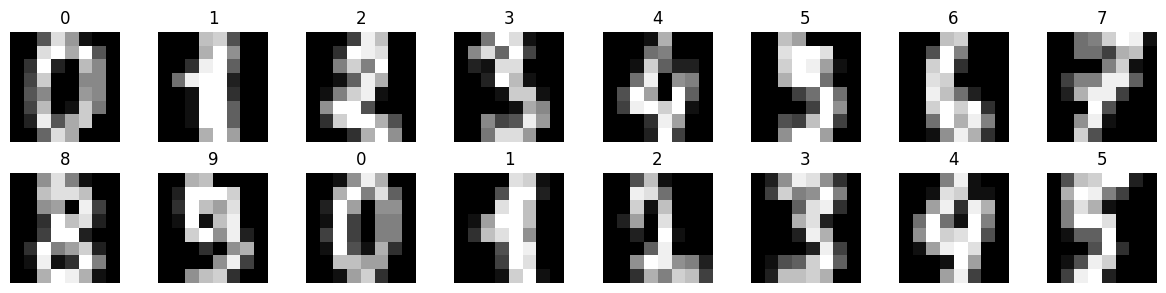

In [4]:

# Visualize a small grid
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, img, label in zip(axes.flatten(), X[:16], y[:16]):
    ax.imshow(img, cmap="gray")
    ax.set_title(int(label))
    ax.axis("off")
plt.tight_layout()
plt.show()



## 2) Convolutions “à la main” avec `F.conv2d` (25 min)

Rappel : `F.conv2d` prend des tenseurs :
- **Input** : (N, C_in, H, W)
- **Kernel/weight** : (C_out, C_in, K_h, K_w)

On va manipuler directement les poids du noyau pour voir l’effet sur l’image.



### Exercice 2 — Noyau identité (3×3)

Construire un noyau 3×3 qui “copie” l’image (type identité : 1 au centre, 0 ailleurs).

#### ✍️ À compléter


In [5]:

# Batch de 8 images
batch = X_t[:8].clone()

kernel = torch.zeros((1, 1, 3, 3), dtype=batch.dtype)
# Mettre 1 au centre du noyau
kernel[...] = ...

out = F.conv2d(batch, kernel, bias=None, stride=1, padding=0)
print("out shape:", out.shape)


TypeError: can't assign a ellipsis to a torch.FloatTensor

#### ✅ Correction

In [6]:

batch = X_t[:8].clone()

kernel = torch.zeros((1, 1, 3, 3), dtype=batch.dtype)
kernel[0, 0, 1, 1] = 1.0

out = F.conv2d(batch, kernel, bias=None, stride=1, padding=0)
print("out shape:", out.shape)  # (8,1,6,6) car pas de padding


out shape: torch.Size([8, 1, 6, 6])



### Visualiser entrée vs sortie

**Question** : pourquoi la taille passe de 8×8 à 6×6 ?


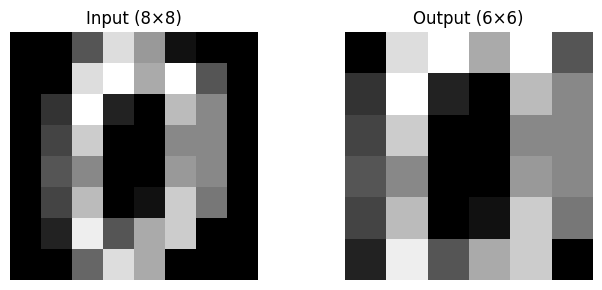

In [7]:

idx = 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))
ax1.imshow(batch[idx, 0].numpy(), cmap="gray")
ax1.set_title("Input (8×8)")
ax1.axis("off")

ax2.imshow(out[idx, 0].detach().numpy(), cmap="gray")
ax2.set_title("Output (6×6)")
ax2.axis("off")
plt.tight_layout()
plt.show()



### Exercice 3 — Détection de contours (Sobel / Laplacien)

Tester un filtre **Sobel horizontal** (ou vertical) et observer les zones mises en évidence.

#### ✍️ À compléter


out_sobel shape: torch.Size([8, 1, 6, 6])


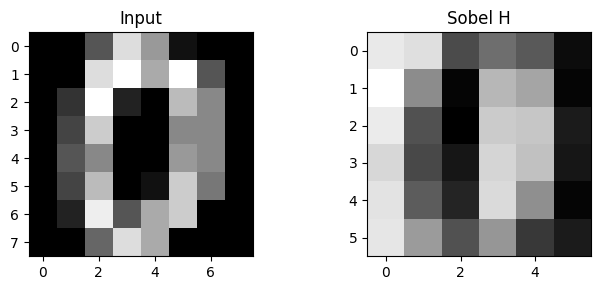

In [8]:

sobel_h = torch.tensor(
    [[[[-1, 0, 1],
       [-2, 0, 2],
       [-1, 0, 1]]]],
    dtype=torch.float32
)

out_sobel = F.conv2d(batch, sobel_h, stride=1, padding=0)
print("out_sobel shape:", out_sobel.shape)

# Visualisation (entrée vs sobel)
idx = 0
plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
plt.imshow(batch[idx,0], cmap="gray")
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(out_sobel[idx,0].detach(), cmap="gray")
plt.title("Sobel H")

plt.tight_layout()
plt.show()



> Variante : essayez aussi Laplacien :
\[
\begin{bmatrix}
0 & 1 & 0\\
1 & -4 & 1\\
0 & 1 & 0
\end{bmatrix}
\]


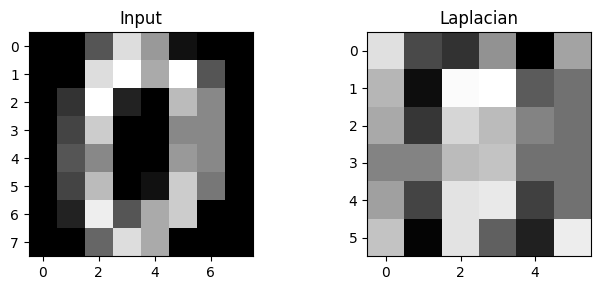

In [9]:

laplacian = torch.tensor(
    [[[[0, 1, 0],
       [1,-4, 1],
       [0, 1, 0]]]], dtype=torch.float32
)

out_lap = F.conv2d(batch, laplacian, stride=1, padding=0)

idx = 0
plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
plt.imshow(batch[idx,0], cmap="gray")
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(out_lap[idx,0].detach(), cmap="gray")
plt.title("Laplacian")

plt.tight_layout()
plt.show()



## 3) Hyperparamètres & dimensions (20 min)

Formule (sans dilation) :
\[
H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1
\]

Avec dilation \(D\), le **kernel effectif** vaut :
\[
K_{eff} = D\cdot(K-1)+1
\]
et on remplace \(K\) par \(K_{eff}\) dans la formule.



### Exercice 4 — Prédire la taille avant d’exécuter

1) Avec `padding=1` et `stride=2`, que vaut la sortie (H_out, W_out) pour une entrée 8×8 et un kernel 3×3 ?  
2) Vérifier avec PyTorch.

#### ✍️ À compléter


In [10]:

out_hp = F.conv2d(batch, sobel_h, stride=2, padding=1)
print("out_hp shape:", out_hp.shape)  # (N, C_out=1, H_out, W_out)


out_hp shape: torch.Size([8, 1, 4, 4])


#### ✅ Correction (calcul)


Entrée 8, kernel 3, padding 1, stride 2 :
\[
H_{out}=\left\lfloor \frac{8 +2\cdot 1 -3}{2}\right\rfloor +1
=\left\lfloor \frac{7}{2}\right\rfloor +1
=3+1=4
\]
Donc sortie : **(N, 1, 4, 4)**.



### Exercice 5 — Dilation (optionnel mais instructif)

Tester `dilation=2` avec un kernel 3×3.  
Quel est le kernel effectif \(K_{eff}\) ? Quelle taille de sortie attendue (sans padding, stride=1) ?


In [11]:

out_dil = F.conv2d(batch, sobel_h, stride=1, padding=0, dilation=2)
print("out_dil shape:", out_dil.shape)


out_dil shape: torch.Size([8, 1, 4, 4])



#### ✅ Correction (calcul)

\(K_{eff} = 2\cdot(3-1)+1 = 5\).  
Sans padding, stride 1 : \(H_{out} = 8 - 5 + 1 = 4\).  
Donc **(N,1,4,4)**.



## 4) Mini-CNN de classification (30 min)

On va entraîner un petit CNN sur **digits** (10 classes).  
Pipeline :
- Split train/test
- Dataloaders
- Modèle `SmallCNN`
- Boucle d’entraînement courte


In [12]:

from torch.utils.data import TensorDataset, DataLoader

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_t, y_t, test_size=0.2, random_state=0, stratify=y_t.numpy()
)

train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

print("Train:", len(train_ds), "| Test:", len(test_ds))


Train: 1437 | Test: 360



### Exercice 6 — Compléter l’architecture

Architecture minimale :
- `Conv2d(1 → 8, kernel=3)`
- ReLU
- `MaxPool2d(2)`
- Flatten
- `Linear(...) → 10`

#### ✍️ À compléter


In [ ]:

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = ...
        self.pool = ...
        self.fc = ...
        
    def forward(self, x):
        x = ...
        x = ...
        x = ...
        x = ...
        return x

model = SmallCNN().to(device)
model


#### ✅ Correction

In [13]:

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 8, kernel_size=3)  # 8x8 -> 6x6
        self.pool = nn.MaxPool2d(2)                 # 6x6 -> 3x3
        self.fc = nn.Linear(8*3*3, 10)

    def forward(self, x):
        x = self.conv(x)
        x = F.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

model = SmallCNN().to(device)
model


SmallCNN(
  (conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=72, out_features=10, bias=True)
)


### Entraînement

On entraîne rapidement (quelques epochs) et on mesure l’accuracy test.


In [14]:

def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.numel()
    return correct / total

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 16):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    test_acc = accuracy(model, test_loader)
    if epoch in [1, 5, 10, 15]:
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | test_acc={test_acc*100:.2f}%")


Epoch 01 | train_loss=2.2664 | test_acc=35.00%
Epoch 05 | train_loss=1.7938 | test_acc=82.22%
Epoch 10 | train_loss=0.9751 | test_acc=86.11%
Epoch 15 | train_loss=0.5670 | test_acc=88.61%



### Confusion rapide (optionnel)

Afficher quelques prédictions.


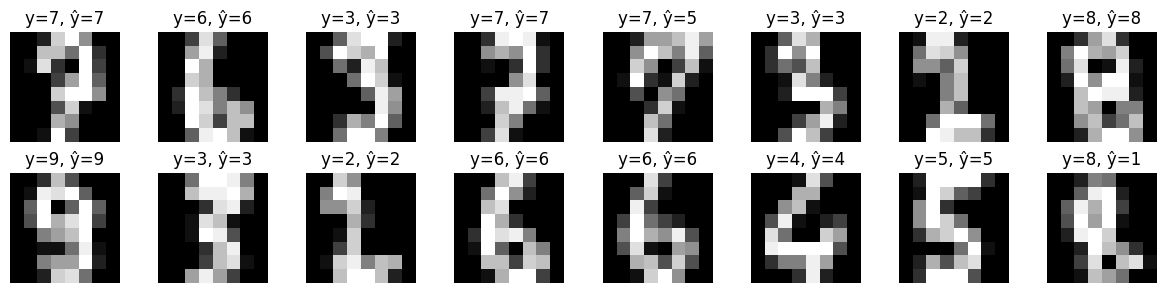

In [15]:

model.eval()
xb, yb = next(iter(test_loader))
xb = xb.to(device)
with torch.no_grad():
    preds = model(xb).argmax(dim=1).cpu()

# show 16 images
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(xb[i,0].cpu(), cmap="gray")
    ax.set_title(f"y={int(yb[i])}, ŷ={int(preds[i])}")
    ax.axis("off")
plt.tight_layout()
plt.show()



# ⭐ BONUS (si avance rapide)

## Bonus A — Ajouter une 2ᵉ couche de convolution

Objectif : construire un réseau un peu plus expressif :
- Conv(1→8, k=3) + ReLU
- Conv(8→16, k=3) + ReLU
- MaxPool(2)
- FC → 10

> **Astuce** : recalculer la taille avant la FC :
- 8×8 → conv3 → 6×6  
- 6×6 → conv3 → 4×4  
- 4×4 → pool2 → 2×2  
Donc entrée FC = 16×2×2 = 64


In [16]:

class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)   # 8->6
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3)  # 6->4
        self.pool  = nn.MaxPool2d(2)                  # 4->2
        self.fc    = nn.Linear(16*2*2, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc(x)

deep_model = DeeperCNN().to(device)
deep_model


DeeperCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

In [17]:

# Entraînement rapide pour comparaison
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(deep_model.parameters(), lr=1e-3)

for epoch in range(1, 11):
    deep_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(deep_model(xb), yb)
        loss.backward()
        optimizer.step()
    if epoch in [1, 5, 10]:
        print(f"Epoch {epoch:02d} | test_acc={accuracy(deep_model, test_loader)*100:.2f}%")


Epoch 01 | test_acc=32.50%
Epoch 05 | test_acc=86.67%
Epoch 10 | test_acc=89.72%



## Bonus B — Tester **sans pooling**

Idée : remplacer `MaxPool2d` par un stride dans la convolution (ex : `stride=2`) et comparer.


In [18]:

class StridedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1)  # 8->4
        self.fc   = nn.Linear(8*4*4, 10)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = torch.flatten(x, start_dim=1)
        return self.fc(x)

stride_model = StridedCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(stride_model.parameters(), lr=1e-3)

for epoch in range(1, 11):
    stride_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(stride_model(xb), yb)
        loss.backward()
        optimizer.step()
    if epoch in [1, 5, 10]:
        print(f"Epoch {epoch:02d} | test_acc={accuracy(stride_model, test_loader)*100:.2f}%")


Epoch 01 | test_acc=21.11%
Epoch 05 | test_acc=85.83%
Epoch 10 | test_acc=89.72%



## Bonus C — Visualiser les filtres appris

On visualise les filtres de la première couche (ici `deep_model.conv1` ou `model.conv`).


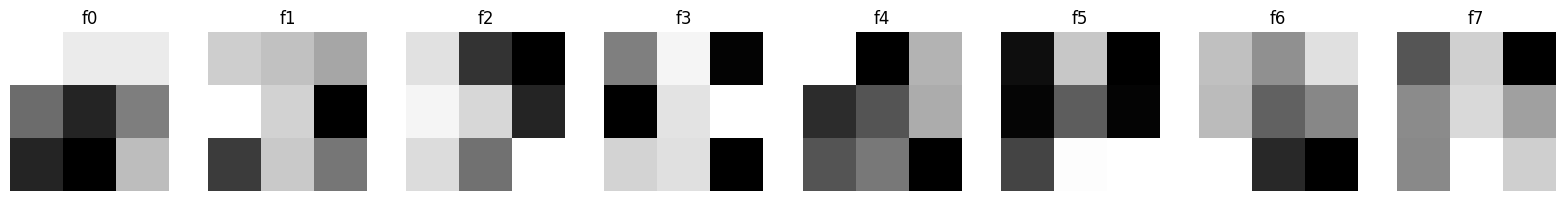

In [19]:

# Choisissez la couche à visualiser :
layer = deep_model.conv1  # ou model.conv

W = layer.weight.detach().cpu()  # (C_out, C_in, K, K)
C_out = W.size(0)

fig, axes = plt.subplots(1, C_out, figsize=(2*C_out, 2))
if C_out == 1:
    axes = [axes]

for i in range(C_out):
    axes[i].imshow(W[i,0], cmap="gray")
    axes[i].set_title(f"f{i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()



## Bonus D — Application à FashionMNIST (plus “réaliste”)

- Images 28×28, 10 classes (vêtements)
- On réutilise l’idée du CNN

> Note : si `torchvision` n’est pas dispo, installer : `pip install torchvision`


In [ ]:

# Bonus FashionMNIST
try:
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    has_torchvision = True
except Exception as e:
    has_torchvision = False
    print("Torchvision not available:", e)

if has_torchvision:
    tfm = transforms.Compose([transforms.ToTensor()])  # (1,28,28) in [0,1]

    train_f = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tfm)
    test_f  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tfm)

    train_loader_f = DataLoader(train_f, batch_size=128, shuffle=True)
    test_loader_f  = DataLoader(test_f, batch_size=256, shuffle=False)

    class FashionCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 28->28
            self.pool  = nn.MaxPool2d(2)                             # 28->14
            self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # 14->14
            self.pool2 = nn.MaxPool2d(2)                             # 14->7
            self.fc    = nn.Linear(32*7*7, 10)

        def forward(self, x):
            x = F.relu(self.conv1(x))
            x = self.pool(x)
            x = F.relu(self.conv2(x))
            x = self.pool2(x)
            x = torch.flatten(x, start_dim=1)
            return self.fc(x)

    fmodel = FashionCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(fmodel.parameters(), lr=1e-3)

    def acc_f(model, loader):
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.numel()
        return correct/total

    for epoch in range(1, 4):  # petit run (TP)
        fmodel.train()
        for xb, yb in train_loader_f:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(fmodel(xb), yb)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch:02d} | test_acc={acc_f(fmodel, test_loader_f)*100:.2f}%")



---
## ✅ Fin du Lab

À emporter :
- Une convolution = produit scalaire glissant + somme sur canaux
- Les hyperparamètres (K, S, P, D) contrôlent fortement les dimensions
- Un CNN simple peut déjà très bien marcher sur digits (et raisonnablement sur FashionMNIST)
